# ARMA

## Import libraries

In [78]:
import warnings
import ccxt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import matplotlib.pyplot as plt
import seaborn as sns

## Constants

In [79]:
TIMEFRAME_DICT = {
    "1m": 60 * 1000,
    "5m": 5 * 60 * 1000,
    "15m": 15 * 60 * 1000,
    "1h": 60 * 60 * 1000,
    "1d": 24 * 60 * 60 * 1000,
}

FREQ_DICT = {
    "1m": "T",
    "5m": "5T",
    "15m": "15T",
    "1h": "h",
    "1d": "D",
}

In [80]:
CLIENT = ccxt.binance()
TICKER = "BTC/USDT"
END_DATE = CLIENT.parse8601("2026-03-31T20:00:00Z")
START_DATE = CLIENT.parse8601("2023-11-03T20:00:00Z")
TIMEFRAME = "1h"
TRAIN_TEST_SPLIT_RATIO = 0.7
WINDOW_SIZE = 240
AR_ORDER_CANDIDATES = range(0, 3)
MA_ORDER_CANDIDATES = range(0, 3)
OUTPUT_VALUE = "log_return_close"
CLASSIFICATION_TARGET = "bin_return_d2d_close"  # same name as XGBoost / Random Forest
RETURN_SCALE = 100.0  # numerical conditioning; forecasts are divided by this factor
START_CASH = 1000.0
BET_PAYOUT = 10.0

## Fetching data

In [81]:
def fetch_data(client, ticker, start_date, end_date, timeframe):
    data = []
    while start_date < end_date:
        limit = 1000 if end_date - start_date >= TIMEFRAME_DICT[timeframe] * 1000 else (end_date - start_date) // (TIMEFRAME_DICT[timeframe])
        if limit <= 0:
            break
        data = data + client.fetch_ohlcv(
            ticker,
            timeframe=timeframe,
            since=start_date,
            limit=limit,
        )
        
        start_date = data[-1][0] + TIMEFRAME_DICT[timeframe] - 1 # -1 to avoid duplicates
    return data

def preprocess_data(data):
    data = pd.DataFrame(
        data,
        columns=["Date", "Open", "High", "Low", "Close", "Volume"]
    )
    # data = data.where(data["Date"] <= END_DATE + 4 * TIMEFRAME_DICT["1h"]).dropna()
    data["Date"] = pd.to_datetime(data["Date"], unit="ms")
    data = data.set_index("Date")
    return data

In [82]:
data = fetch_data(CLIENT, TICKER, START_DATE, END_DATE, TIMEFRAME)
data = preprocess_data(data)
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2023-11-03 20:00:00,34530.71,34659.66,34485.65,34593.90,1046.24789
2023-11-03 21:00:00,34593.90,34700.00,34583.86,34600.93,704.45031
2023-11-03 22:00:00,34600.94,34635.25,34563.54,34628.14,645.16337
2023-11-03 23:00:00,34628.13,34740.00,34611.38,34716.78,894.85032
2023-11-04 00:00:00,34716.78,34725.00,34653.84,34696.65,654.53035


### Verifying continuous of data

In [83]:
all_dates = pd.date_range(start=data.index.min(), end=data.index.max(), freq=FREQ_DICT[TIMEFRAME])
missing = all_dates.difference(data.index)
print(len(missing), missing)
if len(missing) or data.index.has_duplicates or not data.index.is_monotonic_increasing:
    raise ValueError("ARMA requires ordered, unique, continuous candles.")

0 DatetimeIndex([], dtype='datetime64[ms]', freq='h')


## Processing data

In [84]:
data['log_return_close'] = np.log(data['Close'] / data['Close'].shift(1))
data['return_close'] = data['Close'] / data['Close'].shift(1) - 1
data['bin_return_close'] = (data['log_return_close'] > 0).astype(int)
data['bin_return_d2d_close'] = (data['log_return_close'] > data['log_return_close'].shift(1)).astype(int)

In [85]:
data = data.dropna()
data.head()

,Open,High,Low,Close,Volume,log_return_close,return_close,bin_return_close,bin_return_d2d_close
Date,,,,,,,,,
2023-11-03 21:00:00,34593.90,34700.00,34583.86,34600.93,704.45031,0.000203,0.000203,1,0
2023-11-03 22:00:00,34600.94,34635.25,34563.54,34628.14,645.16337,0.000786,0.000786,1,1
2023-11-03 23:00:00,34628.13,34740.00,34611.38,34716.78,894.85032,0.002556,0.002560,1,1
2023-11-04 00:00:00,34716.78,34725.00,34653.84,34696.65,654.53035,-0.000580,-0.000580,0,0
2023-11-04 01:00:00,34696.66,34786.68,34632.47,34768.15,724.86868,0.002059,0.002061,1,1


## Splitting data

In [86]:
series = data[OUTPUT_VALUE].copy()
# Match XGBoost / Random Forest: split before lag generation, then remove
# the first WINDOW_SIZE targets of the test block used there as history.
train_series, remaining_series = train_test_split(
    series, test_size=1-TRAIN_TEST_SPLIT_RATIO, shuffle=False)
val_series, test_block = train_test_split(remaining_series, test_size=0.5, shuffle=False)
if min(len(train_series), len(val_series), len(test_block)) <= WINDOW_SIZE:
    raise ValueError("Every split must contain more than WINDOW_SIZE observations.")
test_series = test_block.iloc[WINDOW_SIZE:].copy()
history_seed = series.loc[series.index < test_series.index[0]].copy()
test_returns = data.loc[test_series.index, "return_close"].copy()
# True previous observed return, never the previous forecast.
previous_returns = series.shift(1).loc[test_series.index]
y_test = data.loc[test_series.index, CLASSIFICATION_TARGET].astype(int)
assert np.array_equal(y_test.to_numpy(), (test_series > previous_returns).astype(int).to_numpy())

In [87]:
split_summary = pd.DataFrame(
    {"raw_samples": [len(train_series), len(val_series), len(test_block)],
     "targets_after_240_lags": [len(train_series)-WINDOW_SIZE,
                                len(val_series)-WINDOW_SIZE, len(test_series)]},
    index=["train", "validation", "test"],
)
split_summary

,raw_samples,targets_after_240_lags
train,14766,14526
validation,3164,2924
test,3165,2925


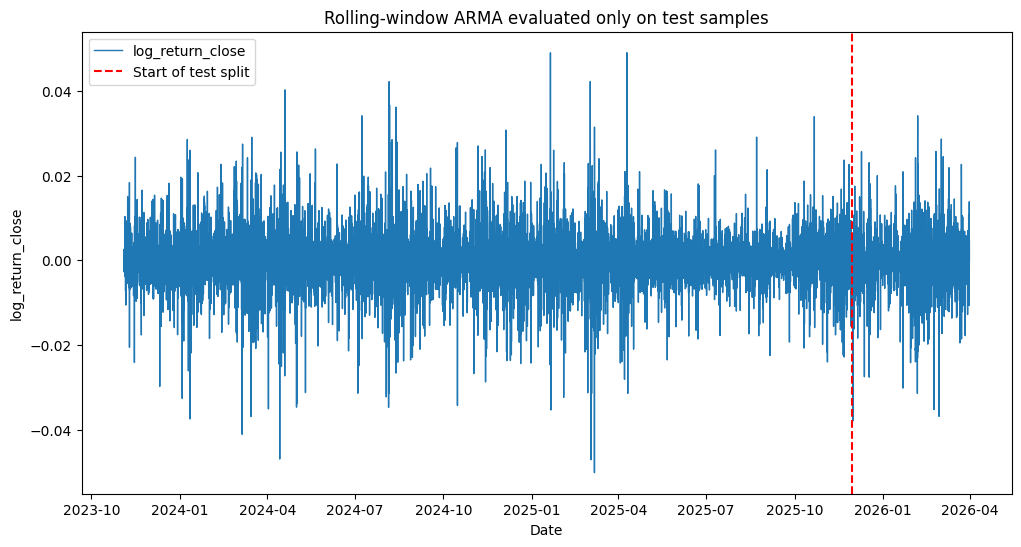

In [88]:
plt.figure(figsize=(12, 6))
plt.plot(series.index, series, label=OUTPUT_VALUE, linewidth=1)
plt.axvline(test_series.index[0], color="red", linestyle="--", label="Start of test split")
plt.title("Rolling-window ARMA evaluated only on test samples")
plt.xlabel("Date")
plt.ylabel("log_return_close")
plt.legend()
plt.show()

In [89]:
def fit_arma(window_series, ar_order, ma_order):
    # ARIMA with d=0 is ARMA(p, q); the model learns continuous log returns.
    values = np.asarray(window_series, dtype=float) * RETURN_SCALE
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", ConvergenceWarning)
        result = ARIMA(values, order=(ar_order, 0, ma_order), trend="c",
                       enforce_stationarity=True, enforce_invertibility=True).fit()
    converged = bool(result.mle_retvals.get("converged", True))
    if not converged or any(issubclass(w.category, ConvergenceWarning) for w in caught):
        raise ValueError("ARMA optimization did not converge.")
    return result


def select_best_arma_model(window_series, ar_candidates, ma_candidates):
    best_result, rejected = None, 0
    # Include ARMA(0,0) as an explicit mean-only candidate.
    for ar_order in ar_candidates:
        for ma_order in ma_candidates:
            try:
                candidate = fit_arma(window_series, ar_order, ma_order)
                prediction = float(np.asarray(candidate.forecast(steps=1)).ravel()[0]) / RETURN_SCALE
                if not np.isfinite(candidate.aic) or not np.isfinite(prediction):
                    raise ValueError("Non-finite AIC or forecast.")
                if best_result is None or candidate.aic < best_result["AIC"]:
                    best_result = {"p": ar_order, "q": ma_order, "AIC": float(candidate.aic),
                                   "prediction": prediction}
            except (ValueError, np.linalg.LinAlgError):
                rejected += 1
    if best_result is None:
        raise RuntimeError("No converged ARMA candidate for this window; inspect data / orders.")
    best_result["rejected_candidates"] = rejected
    return best_result


def forecast_metrics(y_true, y_pred):
    return pd.Series({"MAE": mean_absolute_error(y_true, y_pred),
                      "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))})


def rolling_window_forecast(history_series, forecast_index, window_size,
                            ar_candidates, ma_candidates, actual_values, label="test"):
    history = history_series.copy()
    predictions, diagnostics = [], []
    if not history.index.is_unique or not history.index.is_monotonic_increasing:
        raise ValueError("History must be ordered and unique.")
    if not forecast_index.is_unique or not forecast_index.is_monotonic_increasing:
        raise ValueError("Forecast timestamps must be ordered and unique.")
    if not actual_values.index.is_unique:
        raise ValueError("Actual values must have unique timestamps.")
    if len(history) < window_size or history.index[-1] >= forecast_index[0]:
        raise ValueError("Need 240 past observations strictly before the first forecast.")
    for step, timestamp in enumerate(forecast_index, start=1):
        window = history.iloc[-window_size:]
        assert len(window) == window_size and window.index[-1] < timestamp
        if timestamp - window.index[-1] != pd.Timedelta(milliseconds=TIMEFRAME_DICT[TIMEFRAME]):
            raise ValueError("Forecast must follow the last observed candle by one timeframe.")
        selected = select_best_arma_model(window, ar_candidates, ma_candidates)
        predictions.append(selected["prediction"])
        diagnostics.append({"Date": timestamp, "window_start": window.index[0],
                            "window_end": window.index[-1], "window_samples": len(window),
                            **selected})
        # Observe r[t] only AFTER forecasting t. The next fit uses the latest
        # 240 actual observations, including this now-known value.
        history = pd.concat([history, actual_values.loc[[timestamp]]])
        if step % 100 == 0 or step == len(forecast_index):
            print(f"{label}: processed {step}/{len(forecast_index)} steps", flush=True)
    return (pd.Series(predictions, index=forecast_index, name="predicted_log_return"),
            pd.DataFrame(diagnostics).set_index("Date"))

In [90]:
print(f"Rolling ARMA window: {WINDOW_SIZE} actual observations; horizon: 1 candle")
print(f"Orders selected by AIC on each past window: p={list(AR_ORDER_CANDIDATES)}, q={list(MA_ORDER_CANDIDATES)}")
print("Classification: predicted log return > last observed log return.")
print(f"Test targets match the lagged XGBoost/RF split: {len(test_series)} samples.")
print("ARMA is refitted at every step; testing all orders can take a long time.")

Rolling ARMA window: 240 actual observations; horizon: 1 candle
Orders selected by AIC on each past window: p=[0, 1, 2], q=[0, 1, 2]
Classification: predicted log return > last observed log return.
Test targets match the lagged XGBoost/RF split: 2925 samples.
ARMA is refitted at every step; testing all orders can take a long time.


## Rolling ARMA fitting

In [91]:
test_forecast, selected_orders_df = rolling_window_forecast(
    history_series=history_seed,
    forecast_index=test_series.index,
    window_size=WINDOW_SIZE,
    ar_candidates=AR_ORDER_CANDIDATES,
    ma_candidates=MA_ORDER_CANDIDATES,
    actual_values=series,
    label="test",
)

test: processed 100/2925 steps
test: processed 200/2925 steps
test: processed 300/2925 steps
test: processed 400/2925 steps
test: processed 500/2925 steps
test: processed 600/2925 steps
test: processed 700/2925 steps
test: processed 800/2925 steps
test: processed 900/2925 steps
test: processed 1000/2925 steps
test: processed 1100/2925 steps
test: processed 1200/2925 steps
test: processed 1300/2925 steps
test: processed 1400/2925 steps
test: processed 1500/2925 steps
test: processed 1600/2925 steps
test: processed 1700/2925 steps
test: processed 1800/2925 steps
test: processed 1900/2925 steps
test: processed 2000/2925 steps
test: processed 2100/2925 steps
test: processed 2200/2925 steps
test: processed 2300/2925 steps
test: processed 2400/2925 steps
test: processed 2500/2925 steps
test: processed 2600/2925 steps
test: processed 2700/2925 steps
test: processed 2800/2925 steps
test: processed 2900/2925 steps
test: processed 2925/2925 steps


In [92]:
print(f"Rejected candidate fits: {selected_orders_df.rejected_candidates.sum()}")
selected_orders_df.head(10)

Rejected candidate fits: 1637


,window_start,window_end,window_samples,p,q,AIC,prediction,rejected_candidates
Date,,,,,,,,
2025-11-29 23:00:00,2025-11-19 23:00:00,2025-11-29 22:00:00,240,0,0,434.259066,0.000012,0
2025-11-30 00:00:00,2025-11-20 00:00:00,2025-11-29 23:00:00,240,0,0,430.264802,-0.000034,0
2025-11-30 01:00:00,2025-11-20 01:00:00,2025-11-30 00:00:00,240,0,0,429.898869,-0.000046,0
2025-11-30 02:00:00,2025-11-20 02:00:00,2025-11-30 01:00:00,240,0,0,428.206179,-0.000076,0
2025-11-30 03:00:00,2025-11-20 03:00:00,2025-11-30 02:00:00,240,0,0,428.249076,-0.000082,0
2025-11-30 04:00:00,2025-11-20 04:00:00,2025-11-30 03:00:00,240,0,0,428.228406,-0.000070,0
2025-11-30 05:00:00,2025-11-20 05:00:00,2025-11-30 04:00:00,240,0,0,427.279546,-0.000095,0
2025-11-30 06:00:00,2025-11-20 06:00:00,2025-11-30 05:00:00,240,0,0,426.905525,-0.000083,0
2025-11-30 07:00:00,2025-11-20 07:00:00,2025-11-30 06:00:00,240,0,0,425.564021,-0.000049,0


## Verifying model

In [93]:
comparison_df = pd.DataFrame({
    "y_true": test_series,
    "y_pred": test_forecast,
    "previous_log_return": previous_returns,
    "true_class": y_test,
})
# No differencing of consecutive forecasts: compare forecast r[t] to observed r[t-1].
comparison_df["predicted_class"] = (
    comparison_df.y_pred > comparison_df.previous_log_return
).astype(int)
y_pred = comparison_df.predicted_class
comparison_df.head(10)

,y_true,y_pred,previous_log_return,true_class,predicted_class
Date,,,,,
2025-11-29 23:00:00,0.000544,0.000012,-0.002813,1,1
2025-11-30 00:00:00,0.001007,-0.000034,0.000544,1,0
2025-11-30 01:00:00,0.000213,-0.000046,0.001007,0,0
2025-11-30 02:00:00,-0.001297,-0.000076,0.000213,0,0
2025-11-30 03:00:00,0.001253,-0.000082,-0.001297,1,1
2025-11-30 04:00:00,-0.000565,-0.000070,0.001253,0,0
2025-11-30 05:00:00,-0.000818,-0.000095,-0.000565,0,1
2025-11-30 06:00:00,0.001265,-0.000083,-0.000818,1,1
2025-11-30 07:00:00,0.000764,-0.000049,0.001265,0,0


In [94]:
print(f"Test classification report — {CLASSIFICATION_TARGET}")
print(classification_report(y_test, y_pred, labels=[0, 1],
      target_names=["Return not higher", "Return higher"], zero_division=0, digits=4))
print("Continuous log-return forecast metrics:")
for name, value in forecast_metrics(comparison_df.y_true, comparison_df.y_pred).items():
    print(f"{name}: {value:.6f}")

Test classification report — bin_return_d2d_close
                   precision    recall  f1-score   support

Return not higher     0.7534    0.7488    0.7511      1485
    Return higher     0.7426    0.7472    0.7449      1440

         accuracy                         0.7480      2925
        macro avg     0.7480    0.7480    0.7480      2925
     weighted avg     0.7481    0.7480    0.7480      2925

Continuous log-return forecast metrics:
MAE: 0.003521
RMSE: 0.005369


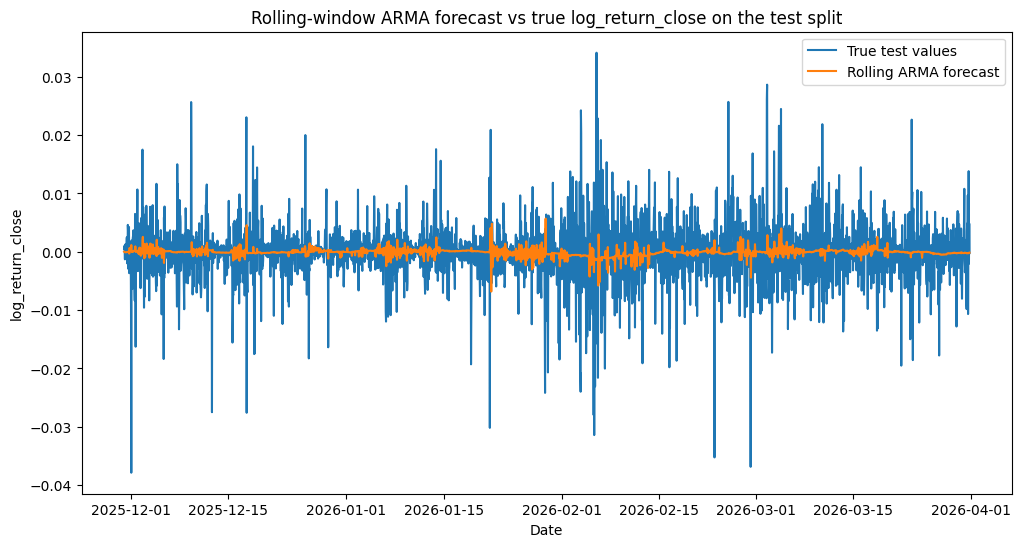

In [95]:
plt.figure(figsize=(12, 6))
plt.plot(comparison_df.index, comparison_df["y_true"], label="True test values")
plt.plot(comparison_df.index, comparison_df["y_pred"], label="Rolling ARMA forecast")
plt.title("Rolling-window ARMA forecast vs true log_return_close on the test split")
plt.xlabel("Date")
plt.ylabel("log_return_close")
plt.legend()
plt.show()

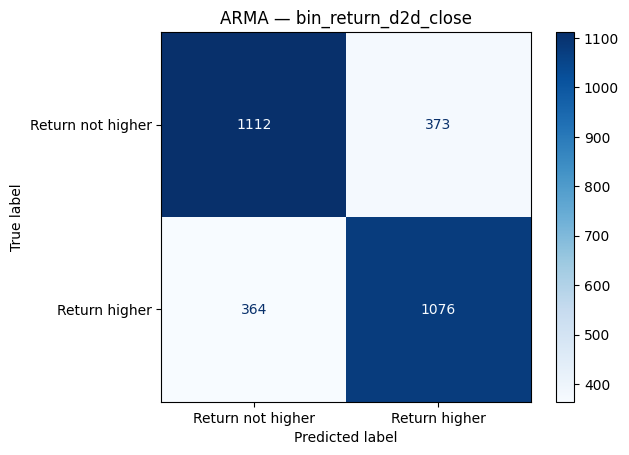

In [96]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=[0, 1],
    display_labels=["Return not higher", "Return higher"], cmap="Blues")
plt.title(f"ARMA — {CLASSIFICATION_TARGET}")
plt.show()

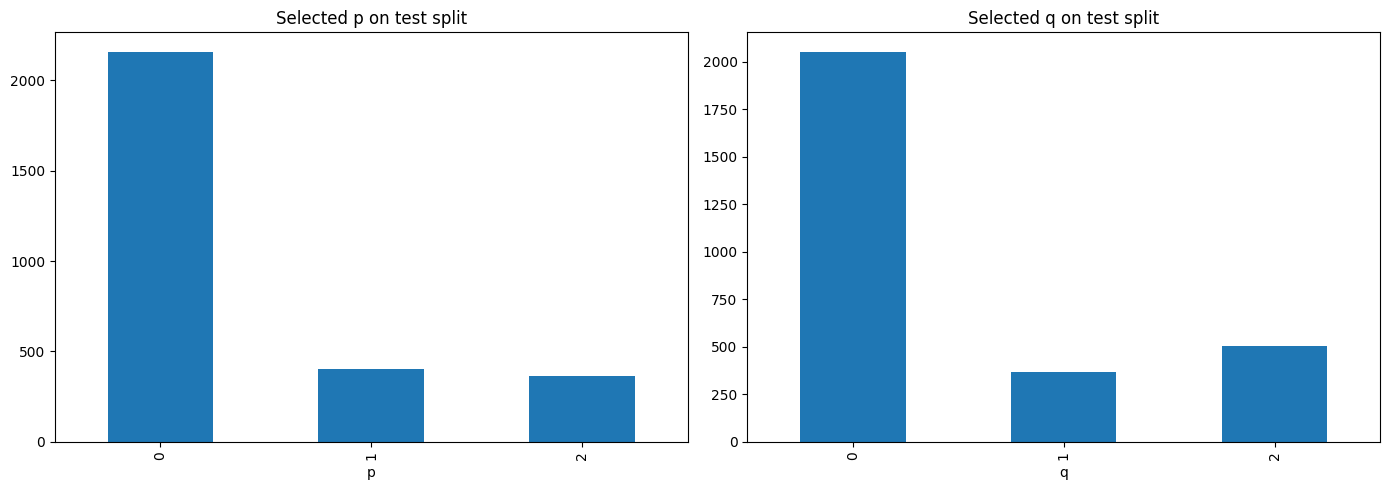

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
selected_orders_df["p"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Selected p on test split")
selected_orders_df["q"].value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Selected q on test split")
axes[0].set_xlabel("p")
axes[1].set_xlabel("q")
plt.tight_layout()
plt.show()

## Backtesting model

Final cash: 2190.00
Total return: 119.00%
Price direction bet accuracy: 0.5203
Strategy annualized Sharpe (risk-free=0.0%): 4.2414
Buy and hold return: -25.25%
Buy and hold annualized Sharpe: -1.5082


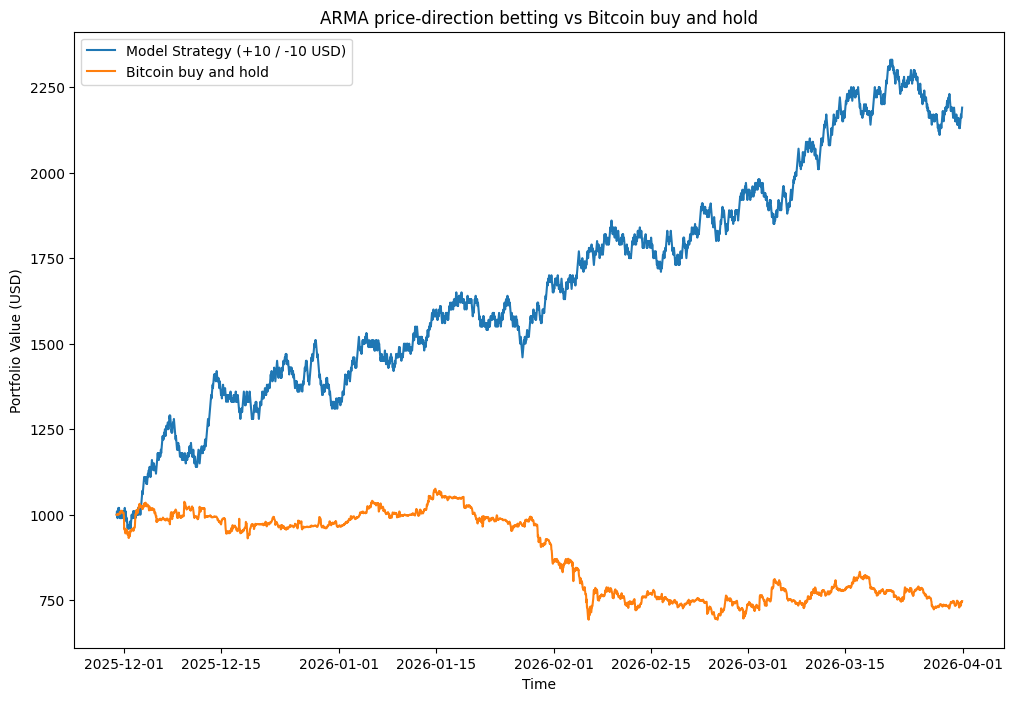

In [98]:
# Match the requested strategy: interpret predicted class 1 as UP and 0 as DOWN.
# ARMA's classification target remains bin_return_d2d_close; price-direction
# betting accuracy below is therefore a different metric from its report.
y_return = test_returns.loc[comparison_df.index].to_numpy()
signal = np.asarray(y_pred, dtype=int).ravel()
assert len(y_return) == len(signal)
start_cash = START_CASH
cash = start_cash
movement_list = [cash]
for prediction, actual_return in zip(signal, y_return):
    if prediction == 1:
        cash += BET_PAYOUT if actual_return > 0 else -BET_PAYOUT
    else:
        cash += BET_PAYOUT if actual_return < 0 else -BET_PAYOUT
    movement_list.append(cash)
# As in the supplied example, zero price change loses for either direction.
# This fixed-stake simulation continues even if capital reaches zero.

settlement_index = comparison_df.index + pd.Timedelta(milliseconds=TIMEFRAME_DICT[TIMEFRAME])
curve_index = pd.DatetimeIndex([comparison_df.index[0]]).append(settlement_index)
strategy_curve = pd.Series(movement_list, index=curve_index, name="Model Strategy")
# Compound actual simple returns: cumsum is only an approximation to buy and hold.
buy_and_hold_curve = pd.Series(
    np.r_[start_cash, start_cash * np.cumprod(1 + y_return)],
    index=curve_index, name="Bitcoin buy and hold")

RISK_FREE_ANNUAL = 0.0
# Crypto trades 24/7: 8760 hourly periods per 365-day year.
periods_per_year = (365 * 24 * 60 * 60 * 1000) / TIMEFRAME_DICT[TIMEFRAME]

def annualized_sharpe(equity, periods_per_year, risk_free_annual=0.0):
    equity = np.asarray(equity, dtype=float)
    if (len(equity) < 3 or not np.isfinite(equity).all()
            or (equity <= 0).any()):
        return np.nan  # Percentage-return Sharpe is not reported after insolvency.
    returns = np.diff(equity) / equity[:-1]
    risk_free_per_period = np.expm1(np.log1p(risk_free_annual) / periods_per_year)
    excess_returns = returns - risk_free_per_period
    volatility = excess_returns.std(ddof=1)
    if np.isclose(volatility, 0.0):
        return np.nan
    # Conventional square-root annualization; not adjusted for autocorrelation.
    return np.sqrt(periods_per_year) * excess_returns.mean() / volatility

strategy_sharpe = annualized_sharpe(strategy_curve, periods_per_year, RISK_FREE_ANNUAL)
buy_and_hold_sharpe = annualized_sharpe(buy_and_hold_curve, periods_per_year, RISK_FREE_ANNUAL)
backtest_results = comparison_df[["true_class", "predicted_class"]].copy()
backtest_results["price_return"] = y_return
backtest_results["pnl_usd"] = np.diff(movement_list)
backtest_results["cash"] = movement_list[1:]

print(f"Final cash: {cash:.2f}")
print(f"Total return: {(cash - start_cash) / start_cash * 100:.2f}%")
print(f"Price direction bet accuracy: {(backtest_results.pnl_usd > 0).mean():.4f}")
print(f"Strategy annualized Sharpe (risk-free={RISK_FREE_ANNUAL:.1%}): {strategy_sharpe:.4f}")
print(f"Buy and hold return: {(buy_and_hold_curve.iloc[-1] / start_cash - 1) * 100:.2f}%")
print(f"Buy and hold annualized Sharpe: {buy_and_hold_sharpe:.4f}")
if (strategy_curve <= 0).any():
    print("Strategy reached non-positive capital: Sharpe is undefined (NaN).")
plt.figure(figsize=(12, 8))
plt.plot(strategy_curve.index, strategy_curve, label="Model Strategy (+10 / -10 USD)")
plt.plot(buy_and_hold_curve.index, buy_and_hold_curve, label="Bitcoin buy and hold")
plt.xlabel("Time")
plt.ylabel("Portfolio Value (USD)")
plt.title("ARMA price-direction betting vs Bitcoin buy and hold")
plt.legend()
plt.show()